Размер исходных данных: (19735, 29)
Все нужные колонки присутствуют.
До удаления NaN: X=(19735, 25), y=(19735,)
После удаления NaN: X=(19735, 25)
Linear Regression    MAE=52.55 RMSE=91.17 R2=0.1694
Random Forest        MAE=32.06 RMSE=67.88 R2=0.5395
Gradient Boosting    MAE=47.24 RMSE=85.81 R2=0.2641

✅ Лучшая модель: Random Forest (R2=0.5395)

Финальные метрики на тесте:
  MAE  = 32.06 Вт·ч
  RMSE = 67.88 Вт·ч
  R2   = 0.5395


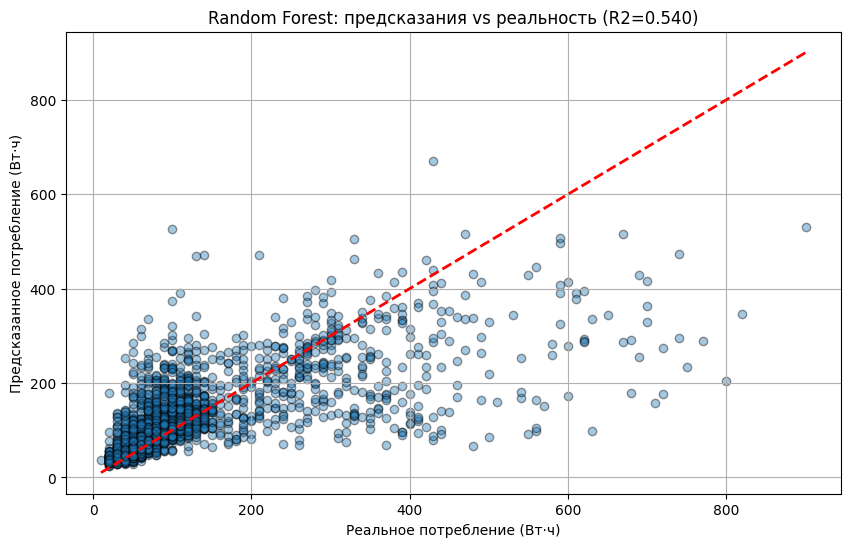

Модель и список признаков сохранены в '../models/'


In [1]:
# %% [markdown]
# # Прогнозирование энергопотребления (упрощённые признаки)
# ## Только те параметры, которые можно ввести вручную

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import os

# %%
# 1. Загрузка данных
df = pd.read_csv('../data/energydata_complete.csv')
print("Размер исходных данных:", df.shape)

# %%
# 2. Отбираем только нужные колонки (которые будем использовать в приложении)
# Список признаков, которые мы будем запрашивать у пользователя:
simple_features = [
    'lights',
    'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4',
    'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9',
    'T_out', 'RH_out', 'Press_mm_hg', 'Windspeed', 'Visibility', 'Tdewpoint'
]

target = 'Appliances'

# Проверяем, что все колонки есть в датасете
missing = [col for col in simple_features if col not in df.columns]
if missing:
    print("Предупреждение: отсутствуют колонки", missing)
else:
    print("Все нужные колонки присутствуют.")

# %%
# 3. Создаём X и y
X = df[simple_features].copy()
y = df[target].copy()

# Удаляем строки с пропусками (если есть)
print(f"До удаления NaN: X={X.shape}, y={y.shape}")
X = X.dropna()
y = y[X.index]  # синхронизируем
print(f"После удаления NaN: X={X.shape}")

# %%
# 4. Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# %%
# 5. Обучаем модели
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'model': model}
    print(f"{name:20} MAE={mae:.2f} RMSE={rmse:.2f} R2={r2:.4f}")

# %%
# 6. Выбираем лучшую модель (по R2)
best_name = max(results, key=lambda x: results[x]['R2'])
best_model = results[best_name]['model']
print(f"\n✅ Лучшая модель: {best_name} (R2={results[best_name]['R2']:.4f})")

# %%
# 7. Финальная оценка на тесте
y_pred_best = best_model.predict(X_test)
final_r2 = r2_score(y_test, y_pred_best)
final_mae = mean_absolute_error(y_test, y_pred_best)
print(f"\nФинальные метрики на тесте:")
print(f"  MAE  = {final_mae:.2f} Вт·ч")
print(f"  RMSE = {np.sqrt(mean_squared_error(y_test, y_pred_best)):.2f} Вт·ч")
print(f"  R2   = {final_r2:.4f}")

# %%
# 8. График
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred_best, alpha=0.4, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Реальное потребление (Вт·ч)')
plt.ylabel('Предсказанное потребление (Вт·ч)')
plt.title(f'{best_name}: предсказания vs реальность (R2={final_r2:.3f})')
plt.grid(True)
plt.show()

# %%
# 9. Сохраняем модель и список признаков
os.makedirs('../models', exist_ok=True)
joblib.dump(best_model, '../models/best_energy_model.pkl')
joblib.dump(simple_features, '../models/feature_names.pkl')
print("Модель и список признаков сохранены в '../models/'")